# Image segmentation with the heat semigroup

We implement the image segmentation model from [Threshold Dynamics for the Piecewise Constant
Mumford-Shah Functional](https://ww3.math.ucla.edu/camreport/cam04-63.pdf) with a few moderations.

Firstly, we split the dynamics into 3 steps as suggested in pages 16-17 of the paper.

We also modify the first step by applying the heat semigroup to the mask as opposed to directly solving the heat equation (e.g. by numerical methods). The heat semigroup that we use is the Jacobi-Theta semigroup which is the heat semigroup for the square. Furthermore, it has the desired periodic boundary conditions for working with images.

In addition, we have included the K-means as mentioned in [Section 9](https://ww3.math.ucla.edu/camreport/cam04-63.pdf).

(If one wants to see how the process approximates the [curve shortening flow](https://a.carapetis.com/csf/), then set ```
dt=0.5 and lambda_param = 0```)

From a coding perspective, we are grateful for this [repository](https://github.com/nathandking/ImageSegmentation/blob/master/EsedogluTsai/CameraMan.m) as we used this as our basis to work from.

### Grayscale image

First, lets import and display a grayscale image 

In [ ]:
from heatdiff.image import load_image
from heatdiff.visualization import show_image

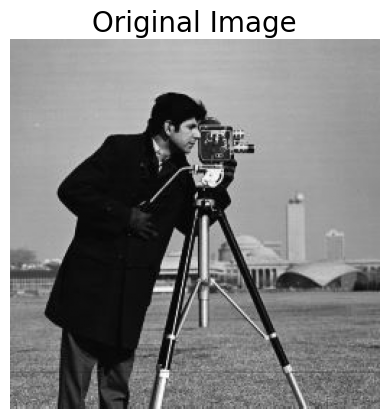

In [ ]:
# Load and show image
image = load_image("images/cameraman.jpg")
show_image(image, title="Original Image")

Next, we create the intial mask at the centre of the image; though you can place the mask wherever you choose to.

In [ ]:
import numpy as np
from numpy.typing import NDArray

In [ ]:
def create_initial_mask(size: tuple, side_length: int) -> NDArray:
    """Create initial square mask in center of image."""
    np.zeros(size)
    cx, cy = size[1] / 2, size[0] / 2  # Center coordinates
    x, y = np.indices(size)
    return (
        (np.abs(x - cx) <= side_length / 2) & (np.abs(y - cy) <= side_length / 2)
    ).astype(float)

We have chosen a square for the initial mask but feel free to experiment with a circle or other polygons.

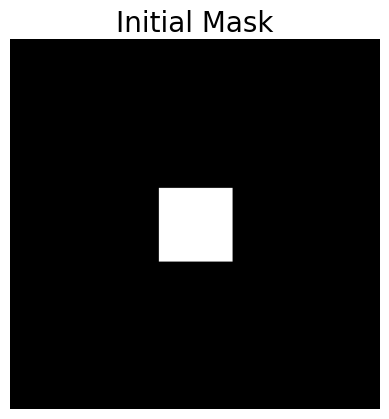

In [ ]:
# Create initial mask
side_length = image.shape[0] // 5
initial_mask = create_initial_mask(image.shape, side_length)
show_image(initial_mask, title="Initial Mask")

Now, we run the segmentation and visualise the final segmentation

In [ ]:
from heatdiff.processing import JacobiThetaSegmenter

In [ ]:
# Create and run segmenter
segmenter = JacobiThetaSegmenter(lambda_param=0.00025, dt=0.5)
result, energies = segmenter.segment(image, initial_mask, max_iter=20)

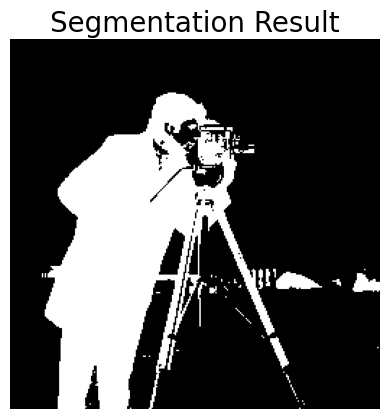

In [ ]:
# Show results
show_image(result, title="Segmentation Result")

Finally, we check for convergence

In [ ]:
import matplotlib.pyplot as plt

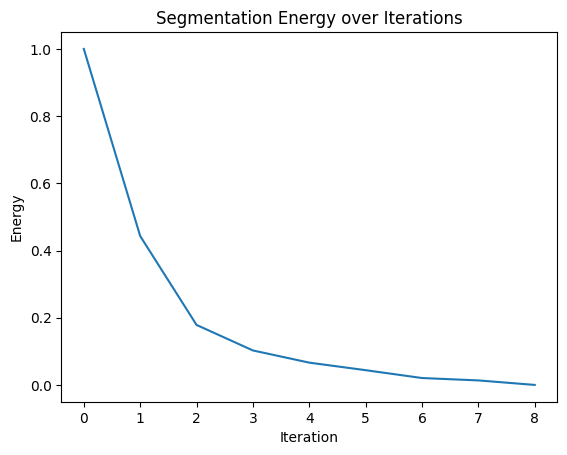

In [ ]:
# Plot energy convergence
plt.figure()
plt.plot(energies)
plt.title("Segmentation Energy over Iterations")
plt.xlabel("Iteration")
plt.ylabel("Energy")
plt.show()

### Colour image 

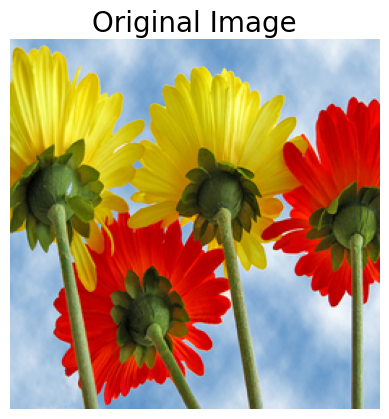

In [ ]:
image = load_image("images/flowers.jpg", grayscale=False)
show_image(image, title="Original Image")

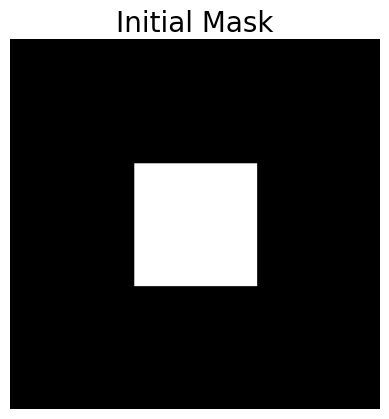

In [ ]:
# Create initial mask
side_length = image.shape[0] // 3
initial_mask = create_initial_mask(image.shape[:2], side_length)
show_image(initial_mask, title="Initial Mask")

In [ ]:
from heatdiff.processing import ColorSegmenter

In [ ]:
# Create and run segmenter
segmenter = ColorSegmenter(lambda_param=0.00025, dt=0.05)
result, energies = segmenter.segment(image, initial_mask, max_iter=50)

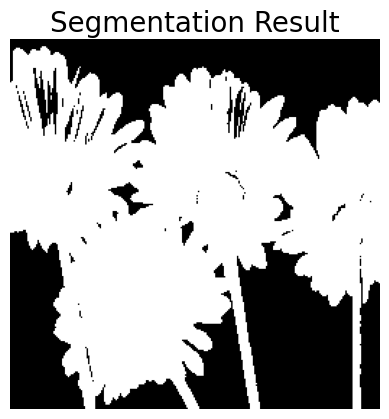

In [ ]:
# Show results
show_image(result, title="Segmentation Result")

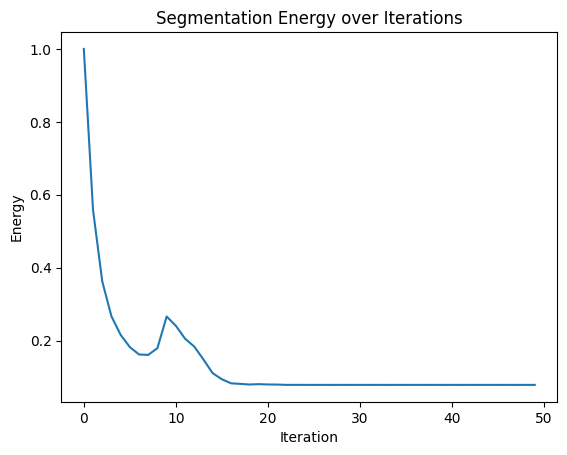

In [ ]:
# Plot energy convergence
plt.figure()
plt.plot(energies)
plt.title("Segmentation Energy over Iterations")
plt.xlabel("Iteration")
plt.ylabel("Energy")
plt.show()

### K-means initialisation 

Finally, we initialise the centres of the K-means algorithm - with K =2 - with the values of C1 and C2 and solve the reaction ODE.

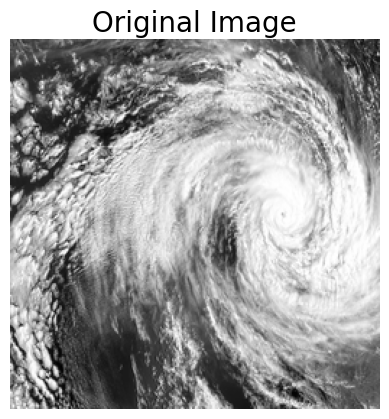

In [ ]:
image = load_image("images/esa_cyclone_sean.jpg")
show_image(image, title="Original Image")

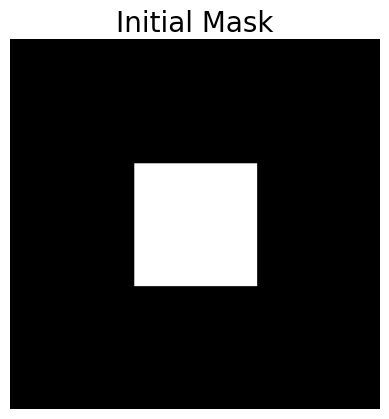

In [ ]:
side_length = image.shape[0] // 3
initial_mask = create_initial_mask(image.shape, side_length)
show_image(initial_mask, title="Initial Mask")

In [ ]:
from heatdiff.processing import KMeansSegmenter

In [ ]:
# Create and run segmenter
segmenter = KMeansSegmenter(lambda_param=0.00025, dt=0.5)
result, energies = segmenter.segment(image, initial_mask, max_iter=20)

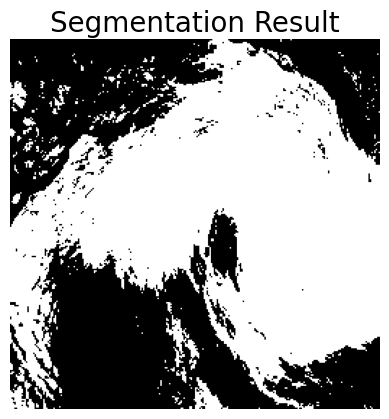

In [ ]:
# Show results
show_image(result, title="Segmentation Result")

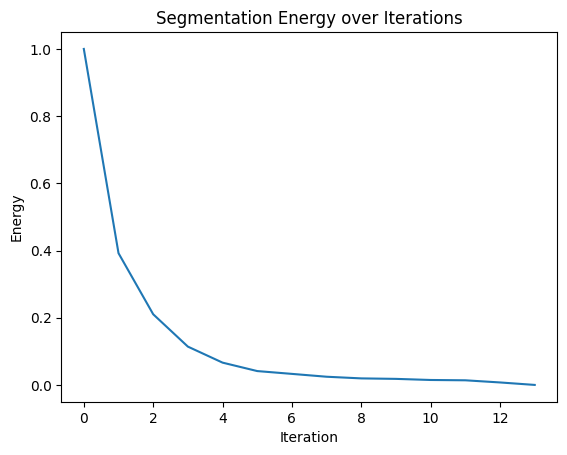

In [ ]:
# Plot energy convergence
plt.figure()
plt.plot(energies)
plt.title("Segmentation Energy over Iterations")
plt.xlabel("Iteration")
plt.ylabel("Energy")
plt.show()